In [1]:
# %%capture cap
!pip install -q ipywidgets
!pip install -q autogluon #scikit-learn==1.5.2 
!apt-get install -q -y graphviz graphviz-dev && pip install -q pydot
!pip install -q pygraphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.1/452.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.8/244.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 3.1 MB/s eta 0:00

In [2]:
import torch
import os
import pydot
import tensorflow as tf

import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from time import time, sleep
from itertools import combinations

from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

2026-03-31 18:45:56.745661: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774982757.002418      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774982757.079160      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774982757.716266      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774982757.716312      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774982757.716315      17 computation_placer.cc:177] computation placer alr

CLASSIC  GREEN   YELLOW 


In [3]:
### Load Data ###
PATH = '/kaggle/input/competitions/playground-series-s6e3/'
submit = pd.read_csv(PATH+'sample_submission.csv')
tn = pd.read_csv(PATH+"train.csv").drop('id', axis=1)

TARGET = tn.columns[-1]
TARGET

'Churn'

In [4]:
## -- Append predicted columns as extra features --
## -- os.walk: Deep search with subfolders --
def dataloader(filepath, train_prefix, test_prefix):    
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    
    print('Loading .npy files: ', end='')
    for (root, dirs, files) in os.walk(filepath):
        for i, file in enumerate(sorted(files), 1):
            if i%5 == 0: print(f'{i}%.. ', end='')
            if file.endswith('.npy') and train_prefix in file:
                train_path = np.load(os.path.join(root, file))
                train_df = pd.concat([train_df, pd.Series(train_path, name=file[4:-4])], axis=1)
            elif file.endswith('.npy') and test_prefix in file:
                test_path = np.load(os.path.join(root, file))
                test_df = pd.concat([test_df, pd.Series(test_path, name=file[5:-4])], axis=1)
    print()

    print('Loading .parquet files: ', end='')
    for (root, dirs, files) in os.walk(filepath):
        for i, file in enumerate(sorted(files), 1):
            if i%5 == 0: print(f"{i}%.. ", end="")
            if file.endswith('.parquet') and train_prefix in file:
                train_path = os.path.join(root, file)
                train_df = pd.concat([train_df, pd.read_parquet(train_path)], axis=1)
            elif file.endswith('.parquet') and test_prefix in file:
                test_path = os.path.join(root, file)
                test_df = pd.concat([test_df, pd.read_parquet(test_path)], axis=1)
    print()
    print(f"Total oof  models: {len(train_df.columns)} || Shape: {train_df.shape}")
    print(f"Total pred models: {len(test_df.columns)} || Shape: {test_df.shape}")
    print()

    return train_df, test_df

def rename_duplicate_cols(df: pd.DataFrame) -> pd.DataFrame:
    original_cols = list(df.columns)
    new_cols = []
    # Track how many times we've seen each original name
    seen = {}

    for col in tqdm(original_cols, desc="Fixing columns"):
        if col not in seen:
            # First occurrence: keep name unchanged
            seen[col] = 1
            new_cols.append(col)
        else:
            # Duplicate: append suffix _k where k starts at 0
            suffix = seen[col] - 1 # 0 for first duplicate, 1 for second,
            new_name = f"{col}_{suffix}"
            new_cols.append(new_name)
            seen[col] += 1

    # Apply new column names
    df_renamed = df.copy()
    df_renamed.columns = new_cols
    print(f"{YELLOW}Columns fixed!!!{RESET}")

    return df_renamed


In [5]:
PATHS = [
    '/kaggle/input/',
]

## -- Load dataframes --
oofs = []
preds  = []

## -- Load train/test datasets --
for p in PATHS:
    tr, ts = dataloader(p, 'oof', 'test')
    oofs.append(tr)
    preds.append(ts)

## -- Concat datasets --
oof_df = pd.concat(oofs, axis=1)
pred_df  = pd.concat(preds, axis=1)

print('Data loaded', oof_df.shape, pred_df.shape)

## -- Drop models if necessary --
for c in oof_df.columns:
    if 'cvStack' in c or 'L3' in c: #
        oof_df.drop([c], axis=1, inplace=True)
        pred_df.drop([c], axis=1, inplace=True)
    elif c == TARGET:
        oof_df.drop([c], axis=1, inplace=True)
        
print('-'*50)
## -- Check for missingness --
print(f'OOF  Null: {oof_df.isna().sum().sum()} | ',end='')
print(f'TEST Null: {pred_df.isna().sum().sum()}')
print('-'*50)

## -- Apply column rename function --
oof_df = rename_duplicate_cols(oof_df)
pred_df = rename_duplicate_cols(pred_df)

print()
print(f'{YELLOW}••••• Updated columns: {oof_df.shape[1]}')

display(oof_df.head(3))
print()
display(pred_df.head(3))

Loading .npy files: 5%.. 10%.. 15%.. 20%.. 25%.. 30%.. 35%.. 40%.. 45%.. 50%.. 55%.. 60%.. 65%.. 70%.. 75%.. 80%.. 85%.. 90%.. 95%.. 100%.. 105%.. 110%.. 115%.. 120%.. 125%.. 130%.. 135%.. 140%.. 145%.. 150%.. 155%.. 160%.. 165%.. 170%.. 175%.. 180%.. 185%.. 
Loading .parquet files: 5%.. 10%.. 15%.. 20%.. 25%.. 30%.. 35%.. 40%.. 45%.. 50%.. 55%.. 60%.. 65%.. 70%.. 75%.. 80%.. 85%.. 90%.. 95%.. 100%.. 105%.. 110%.. 115%.. 120%.. 125%.. 130%.. 135%.. 140%.. 145%.. 150%.. 155%.. 160%.. 165%.. 170%.. 175%.. 180%.. 185%.. 
Total oof  models: 206 || Shape: (594194, 206)
Total pred models: 206 || Shape: (254655, 206)

Data loaded (594194, 206) (254655, 206)
--------------------------------------------------
OOF  Null: 0 | TEST Null: 0
--------------------------------------------------


Fixing columns:   0%|          | 0/199 [00:00<?, ?it/s]

Columns fixed!!!


Fixing columns:   0%|          | 0/199 [00:00<?, ?it/s]

Columns fixed!!!

••••• Updated columns: 199


,kerasV0_512_91511,kerasV0_768_91532,kerasV0_91524,pytabV1_realMLP_918065,pytabV1_tabM_918771,realmlp_91924.csv,realmlp_9194,realmlp_91941,stack_91751,hill_9175,histV2__loss_917701,histV2__roc_auc_917669,histV1__loss_917801,histV1__roc_auc_917785,LGBv10BAG__916928,LGBv10GOSS__917361,LGBv11BAG__918121,LGBv11GOSS__918163,LGBv12BAG__917301,LGBv12GOSS__917503,LGBv1BAG__918237,LGBv1GOSS__918284,LGBv2BAG__918642,LGBv2GOSS__918589,LGBv3BAG__917314,LGBv3GOSS__917564,LGBv4BAG__917765,LGBv4GOSS__917985,LGBv5BAG__91632,LGBv5GOSS__916459,LGBv6BAG__91702,LGBv6GOSS__916954,LGBv7BAG__917208,LGBv7GOSS__917588,LGBv8BAG__917359,LGBv8GOSS__917669,LGBv9BAG__918109,LGBv9GOSS__918304,Trial_1.0_917386,Trial_2.0_917439,XGBv1gbt__917622,XGBv1loss__917622,XGBv1grad__917515,Trial_1.0_917805,Trial_2.0_917778,XGBv1gbt__917903,XGBv1loss__917903,XGBv1grad__91783,Xgb_tabM_pseudo_91882,Xgb_tabM_pseudo_919078,bartzV1_wbart_916967,bartzV1_pbart_918358,cat2V1_bern__91783,cat2V1_loss__917702,catV1_bayes__919199,catV1_bern__918788,catV1_loss__91885,catV1_ord_bayes__919085,catV2_bayes__919243,catV2_bern__918811,catV2_loss__918846,catV2_ord_bayes__919121,h2oV0__916364,h2oV1_20_91791,h2oV2_20_91769,lgb2v1_bag_127_005_917263,lgb2v1_bag_127_007_917269,lgb2v1_goss_127_005_917231,lgb2v1_goss_127_007_917231,lgb2v2_bag_256_916909,lgb2v2_goss_256_916779,lgbv00_bag_256_003_919127,lgbv00_goss_256_003_919215,lgbv0_bag_256_003_919176,lgbv0_goss_256_003_919294,lgbvv1_bag_6_006_919057,lgbvv1_goss_6_006_919182,lgbvv1_bag_5_01_919045,lgbvv1_goss_5_01_919099,lgbvv1_bag_5_03_918996,lgbvv1_goss_5_03_919067,lgbvv1_bag_4_03_91896,lgbvv1_goss_4_03_918975,lgbvv2_bag_6_007_919088,lgbvv2_goss_6_007_91919,lgbvv2_bag_5_01_919091,lgbvv2_goss_5_01_919108,lgbvv3_bag_6_007_91906,lgbvv3_goss_6_007_919236,lgbvv3_bag_5_01_919048,lgbvv3_goss_5_01_919167,lgbvv3_bag_6_007_918412,lgbvv3_goss_6_007_918642,lgbvv4_bag_6_007_919088,lgbvv4_bag_6_005_919093,lgbvv4_goss_6_007_919247,lgbvv4_goss_6_005_919267,lgbvv5_bag_6_007_919078,lgbvv5_bag_6_005_919083,lgbvv5_goss_6_007_91923,lgbvv5_goss_6_005_919259,lgbvv6_bag__005_918959,lgbvv6_goss__005_919268,lgbvv7_bag_005_918934,lgbvv7_goss_005_919245,lgbvv8_bag_256_003_918963,lgbvv8_goss_256_003_919271,lgbvv8_bag_127_005_919019,lgbvv8_bag_127_003_919048,lgbvv8_goss_127_005_919302,lgbvv8_goss_127_003_919309,lgbvv9_bag_256_005_919167,lgbvv9_goss_256_005_919311,lgbvv9_bag_256_003_919171,lgbvv9_goss_256_003_919324,logV1_ohe_cats_first_916667,logV1_ohe_cats_None_916667,logV5_ohe_cats_first_914921,logV5_ohe_cats_None_91492,logV5_ohe_cats_first_915105,logV5_ohe_cats_None_915585,pytabV2_realMLP_918141,pytabV2_tabM_918874,pytabV2_xgb_919243,pytabV2_lgb_919246,pytabV2_cat_Plain_917676,pytabV2_cat_Ordered_917682,pytabV2_mlpPLR_917201,pytabV2_mlpRTDL_917341,pytabV2_resRTDL_917408,tabnetV0_logloss_912635,tabnetV0_auc_912569,tabnetV1_logloss_916624,tabnetV1_auc_916734,tabnetV1_logloss_91688,tabnetV1_auc_916792,tabnetV2__logloss_916788,tabnetV2__auc_916681,tabnetV2_logloss_917032,tabnetV2_auc_916845,tabnetV2_logloss_916684,tabnetV2_auc_915228,tabnetV3_logloss_916319,tabnetV3_auc_915076,tabnetV3_logloss_916771,tabnetV3_auc_916912,tabnetV4_logloss_916102,tabnetV4_auc_916248,tabnetV4_logloss_916769,tabnetV4_auc_916518,tabnetV5_logloss_916655,tabnetV5_auc_916478,tabnetV5_logloss_916786,tabnetV5_auc_916916,tabnetV6_logloss_916461,tabnetV6_auc_915622,xLearn_v1_fm_917331,xLearn_v1_ffm_918503,xLearn_v1_linear_915355,xLearn_v1_fm_917328,xLearn_v1_ffm_918494,xLearn_v1_linear_915363,xLearn_v2_fm_917431,xLearn_v2_ffm_918475,xLearn_v2_linear_91462,xgb2v1_gbt_005_917194,xgb2v1_loss_005_917194,xgb2v2_gbt_005_916962,xgb2v2_loss_005_916826,xgbV2gbt_3_91817,xgbV2gbt_4_918308,xgbV2loss_3_91817,xgbV2loss_4_918308,xgbV2grad_3_918085,xgbV2grad_4_918157,xgbV3gbt_01_918995,xgbV3loss_01_918995,xgbV3grad_01_918871,xgbV3gbt_005_918973,xgbV3loss_005_918973,xgbV3grad_005_918818,xgbvv1gbt_005_918873,xgbvv1loss_005_91874,xgbvv1grad_005_918888,xgbvv2gbt_005_91914,xgbvv2loss_005_919074,xgbvv2grad_005_919039,ydfV0_g

,kerasV0_512_91511,kerasV0_768_91532,kerasV0_91524,pytabV1_realMLP_918065,pytabV1_tabM_918771,realmlp_91924.csv,realmlp_9194,realmlp_91941,stack_91751,hill_9175,histV2__loss_917701,histV2__roc_auc_917669,histV1__loss_917801,histV1__roc_auc_917785,LGBv10BAG__916928,LGBv10GOSS__917361,LGBv11BAG__918121,LGBv11GOSS__918163,LGBv12BAG__917301,LGBv12GOSS__917503,LGBv1BAG__918237,LGBv1GOSS__918284,LGBv2BAG__918642,LGBv2GOSS__918589,LGBv3BAG__917314,LGBv3GOSS__917564,LGBv4BAG__917765,LGBv4GOSS__917985,LGBv5BAG__91632,LGBv5GOSS__916459,LGBv6BAG__91702,LGBv6GOSS__916954,LGBv7BAG__917208,LGBv7GOSS__917588,LGBv8BAG__917359,LGBv8GOSS__917669,LGBv9BAG__918109,LGBv9GOSS__918304,Trial_1.0_917386,Trial_2.0_917439,XGBv1gbt__917622,XGBv1loss__917622,XGBv1grad__917515,Trial_1.0_917805,Trial_2.0_917778,XGBv1gbt__917903,XGBv1loss__917903,XGBv1grad__91783,Xgb_tabM_pseudo_91882,Xgb_tabM_pseudo_919078,bartzV1_wbart_916967,bartzV1_pbart_918358,cat2V1_bern__91783,cat2V1_loss__917702,catV1_bayes__919199,catV1_bern__918788,catV1_loss__91885,catV1_ord_bayes__919085,catV2_bayes__919243,catV2_bern__918811,catV2_loss__918846,catV2_ord_bayes__919121,h2oV0__916364,h2oV1_20_91791,h2oV2_20_91769,lgb2v1_bag_127_005_917263,lgb2v1_bag_127_007_917269,lgb2v1_goss_127_005_917231,lgb2v1_goss_127_007_917231,lgb2v2_bag_256_916909,lgb2v2_goss_256_916779,lgbv00_bag_256_003_919127,lgbv00_goss_256_003_919215,lgbv0_bag_256_003_919176,lgbv0_goss_256_003_919294,lgbvv1_bag_6_006_919057,lgbvv1_goss_6_006_919182,lgbvv1_bag_5_01_919045,lgbvv1_goss_5_01_919099,lgbvv1_bag_5_03_918996,lgbvv1_goss_5_03_919067,lgbvv1_bag_4_03_91896,lgbvv1_goss_4_03_918975,lgbvv2_bag_6_007_919088,lgbvv2_goss_6_007_91919,lgbvv2_bag_5_01_919091,lgbvv2_goss_5_01_919108,lgbvv3_bag_6_007_91906,lgbvv3_goss_6_007_919236,lgbvv3_bag_5_01_919048,lgbvv3_goss_5_01_919167,lgbvv3_bag_6_007_918412,lgbvv3_goss_6_007_918642,lgbvv4_bag_6_007_919088,lgbvv4_bag_6_005_919093,lgbvv4_goss_6_007_919247,lgbvv4_goss_6_005_919267,lgbvv5_bag_6_007_919078,lgbvv5_bag_6_005_919083,lgbvv5_goss_6_007_91923,lgbvv5_goss_6_005_919259,lgbvv6_bag__005_918959,lgbvv6_goss__005_919268,lgbvv7_bag_005_918934,lgbvv7_goss_005_919245,lgbvv8_bag_256_003_918963,lgbvv8_goss_256_003_919271,lgbvv8_bag_127_005_919019,lgbvv8_bag_127_003_919048,lgbvv8_goss_127_005_919302,lgbvv8_goss_127_003_919309,lgbvv9_bag_256_005_919167,lgbvv9_goss_256_005_919311,lgbvv9_bag_256_003_919171,lgbvv9_goss_256_003_919324,logV1_ohe_cats_first_916667,logV1_ohe_cats_None_916667,logV5_ohe_cats_first_914921,logV5_ohe_cats_None_91492,logV5_ohe_cats_first_915105,logV5_ohe_cats_None_915585,pytabV2_realMLP_918141,pytabV2_tabM_918874,pytabV2_xgb_919243,pytabV2_lgb_919246,pytabV2_cat_Plain_917676,pytabV2_cat_Ordered_917682,pytabV2_mlpPLR_917201,pytabV2_mlpRTDL_917341,pytabV2_resRTDL_917408,tabnetV0_logloss_912635,tabnetV0_auc_912569,tabnetV1_logloss_916624,tabnetV1_auc_916734,tabnetV1_logloss_91688,tabnetV1_auc_916792,tabnetV2__logloss_916788,tabnetV2__auc_916681,tabnetV2_logloss_917032,tabnetV2_auc_916845,tabnetV2_logloss_916684,tabnetV2_auc_915228,tabnetV3_logloss_916319,tabnetV3_auc_915076,tabnetV3_logloss_916771,tabnetV3_auc_916912,tabnetV4_logloss_916102,tabnetV4_auc_916248,tabnetV4_logloss_916769,tabnetV4_auc_916518,tabnetV5_logloss_916655,tabnetV5_auc_916478,tabnetV5_logloss_916786,tabnetV5_auc_916916,tabnetV6_logloss_916461,tabnetV6_auc_915622,xLearn_v1_fm_917331,xLearn_v1_ffm_918503,xLearn_v1_linear_915355,xLearn_v1_fm_917328,xLearn_v1_ffm_918494,xLearn_v1_linear_915363,xLearn_v2_fm_917431,xLearn_v2_ffm_918475,xLearn_v2_linear_91462,xgb2v1_gbt_005_917194,xgb2v1_loss_005_917194,xgb2v2_gbt_005_916962,xgb2v2_loss_005_916826,xgbV2gbt_3_91817,xgbV2gbt_4_918308,xgbV2loss_3_91817,xgbV2loss_4_918308,xgbV2grad_3_918085,xgbV2grad_4_918157,xgbV3gbt_01_918995,xgbV3loss_01_918995,xgbV3grad_01_918871,xgbV3gbt_005_918973,xgbV3loss_005_918973,xgbV3grad_005_918818,xgbvv1gbt_005_918873,xgbvv1loss_005_91874,xgbvv1grad_005_918888,xgbvv2gbt_005_91914,xgbvv2loss_005_919074,xgbvv2grad_005_919039,ydfV0_g

In [6]:
print(f"""
-> OOFS shape: {oof_df.shape}
-> TEST shape: {pred_df.shape}
    """)


-> OOFS shape: (594194, 199)
-> TEST shape: (254655, 199)
    


In [7]:
MODELS_PATH = "/kaggle/working/ag_CHURN_models/"
# !rm -r {MODELS_PATH}

In [8]:
from autogluon.tabular import TabularPredictor

In [9]:
## -- RUN 1: Use train data -- 
predictor = TabularPredictor(
                label = TARGET,
         # problem_type = "binary",
          eval_metric = 'roc_auc',
                 path = MODELS_PATH,
    ).fit(
                   train_data = pd.concat([oof_df, tn[TARGET]], axis=1),
                      presets = 'best',
                num_bag_folds = 5,
             dynamic_stacking = False,
             num_stack_levels = 1,
                   time_limit = 3600*4,
                   # auto_stack = False,
                 # num_bag_sets = 2,
                  # ag_args_fit = {'num_cpus': os.cpu_count()},
) 

Preset alias specified: 'best' maps to 'best_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sat Jan 17 11:20:45 UTC 2026
CPU Count:          4
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       25.95 GB / 31.35 GB (82.8%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
Presets specified: ['best']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 14400s
AutoGluon will save models to "/kaggle/working/ag_CHURN_models"
Train Data Rows:    594194
Train Data Columns: 199
Label Column:       Churn
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['No', '

In [10]:
## -- Get Summary -- 
print(f"-> Total models : {len(predictor.model_names())}")
print(f"-> Best model   : {predictor.model_best}\n") 

## -- RUN 1 RESULTS -- 
leaderboard = predictor.leaderboard(silent=True)
leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral")

-> Total models : 16
-> Best model   : WeightedEnsemble_L3



,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3,0.919878,roc_auc,497.960221,11234.588307,0.146507,52.025228,3,True,16
1,WeightedEnsemble_L2,0.919877,roc_auc,124.064198,6180.797537,0.145469,44.534838,2,True,11
2,NeuralNetFastAI_BAG_L1,0.919806,roc_auc,9.388562,1484.936306,9.388562,1484.936306,1,True,8
3,LightGBMXT_BAG_L1,0.919715,roc_auc,5.893511,267.601128,5.893511,267.601128,1,True,1
4,LightGBMXT_BAG_L2,0.919711,roc_auc,404.087367,9143.704888,5.496888,269.216106,2,True,12
5,LightGBM_BAG_L1,0.919689,roc_auc,3.266302,252.594997,3.266302,252.594997,1,True,2
6,XGBoost_BAG_L1,0.919666,roc_auc,10.006929,275.940145,10.006929,275.940145,1,True,9
7,LightGBM_BAG_L2,0.919642,roc_auc,402.441326,9128.430333,3.850847,253.941551,2,True,13
8,CatBoost_BAG_L1,0.919639,roc_auc,0.954417,553.439082,0.954417,553.439082,1,True,5
9,ExtraTreesEntr_BAG_L1,0.919247,roc_auc,85.251481,235.688586,85.251481,235.688586,1,True,7


In [11]:
# ## -- RUN 2: Use original data as extra learning input --
# predictor.fit_pseudolabel(
#                 orig,
#                 use_ensemble = True,
#                 fit_ensemble = True,
#                 time_limit   = 3600*5,
# )

In [12]:
# ## -- Get Summary -- 
# print(f"-> Total models : {len(predictor.model_names())}")
# print(f"-> Best model   : {predictor.model_best}\n") 

# ## -- RUN 2 RESULTS -- 
# leaderboard = predictor.leaderboard(silent=True)
# leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral")

In [13]:
## -- Create folder directory to save predictions --
SAVE_PATH = '/kaggle/working/ag_CHURN_preds/'
FILE_NAME = 'ag_CHURN.parquet'
!mkdir {SAVE_PATH}

In [14]:
%%time
## -- Generate predictions for all models --
ag_multi_test = predictor.predict_proba_multi(pred_df, as_multiclass=False)

## -- Save TEST predictions of all models --
final_test_data = {}
DESC = "Exporting TEST predictions"

for k, v in tqdm(ag_multi_test.items(), desc=DESC):
    k_renamed = k.replace('_', '')
    final_test_data[k_renamed] = v

file_name = f"{SAVE_PATH}test_{FILE_NAME}"

final_test_df = pd.DataFrame(final_test_data)
final_test_df.to_parquet(file_name, index=False)
final_test_df.head()

Exporting TEST predictions:   0%|          | 0/16 [00:00<?, ?it/s]

CPU times: user 6min 24s, sys: 26.6 s, total: 6min 50s
Wall time: 2min 59s


,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestGiniBAGL1,RandomForestEntrBAGL1,CatBoostBAGL1,ExtraTreesGiniBAGL1,ExtraTreesEntrBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,LightGBMLargeBAGL1,WeightedEnsembleL2,LightGBMXTBAGL2,LightGBMBAGL2,RandomForestGiniBAGL2,RandomForestEntrBAGL2,WeightedEnsembleL3
0,0.135718,0.126358,0.096889,0.125155,0.126233,0.128782,0.126406,0.132829,0.129495,0.141000,0.130741,0.134334,0.132744,0.081819,0.079424,0.128399
1,0.000835,0.001126,0.002543,0.000312,0.001204,0.002345,0.000789,0.001410,0.000827,0.047880,0.001198,0.000693,0.001317,0.002567,0.000332,0.001277
2,0.110970,0.109993,0.085209,0.071317,0.111074,0.110717,0.109366,0.116126,0.109107,0.132251,0.111328,0.111479,0.115720,0.081981,0.105649,0.110100
3,0.003499,0.003464,0.002762,0.001226,0.002396,0.003350,0.003452,0.003529,0.003244,0.048302,0.003234,0.003440,0.003734,0.002748,0.001120,0.003225
4,0.532256,0.530426,0.535983,0.557969,0.532610,0.542299,0.520995,0.543874,0.526658,0.466245,0.539353,0.531456,0.532858,0.543543,0.564144,0.539788


In [15]:
%%time
## -- Get OOF predictions of all models --
ag_multi_oof_preds = {}
DESC1 = "Processing OOF probabilities"

for model in tqdm(predictor.model_names(), desc=DESC1):
    ag_multi_oof_preds[model] = predictor.predict_proba_oof(
                                             model = model,
                                        train_data = pd.concat([oof_df, tn[TARGET]], axis=1),
                                     as_multiclass = False,
                                )

final_oof_data = {}
DESC2 = "Exporting OOF predictions"

for k, v in tqdm(ag_multi_oof_preds.items(), desc=DESC2):
    k_renamed = k.replace('_', '')
    final_oof_data[k_renamed] = v

file_name = f"{SAVE_PATH}oof_{FILE_NAME}"

final_oof_df = pd.DataFrame(final_oof_data)
final_oof_df.to_parquet(file_name, index=False)
final_oof_df.head()

Processing OOF probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

Exporting OOF predictions:   0%|          | 0/16 [00:00<?, ?it/s]

CPU times: user 4.79 s, sys: 13 s, total: 17.8 s
Wall time: 22.4 s


,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestGiniBAGL1,RandomForestEntrBAGL1,CatBoostBAGL1,ExtraTreesGiniBAGL1,ExtraTreesEntrBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,LightGBMLargeBAGL1,WeightedEnsembleL2,LightGBMXTBAGL2,LightGBMBAGL2,RandomForestGiniBAGL2,RandomForestEntrBAGL2,WeightedEnsembleL3
0,0.008583,0.010368,0.010524,0.003380,0.013860,0.012103,0.009293,0.014364,0.007653,0.067392,0.012187,0.008764,0.009649,0.010503,0.003176,0.012211
1,0.001024,0.001378,0.002507,0.000418,0.001104,0.002319,0.000826,0.000725,0.001543,0.053719,0.000930,0.000963,0.001119,0.002545,0.000379,0.001001
2,0.280552,0.282943,0.219186,0.262323,0.278971,0.287731,0.309052,0.263191,0.280644,0.262846,0.269994,0.283374,0.258719,0.184263,0.254494,0.265368
3,0.722422,0.732939,0.659764,0.622412,0.661630,0.638744,0.723407,0.687474,0.740877,0.698349,0.693915,0.719352,0.713661,0.606457,0.690406,0.689220
4,0.773891,0.777254,0.657960,0.740243,0.773660,0.804355,0.786000,0.769466,0.782739,0.649511,0.770895,0.782239,0.741268,0.741472,0.643179,0.769352


In [16]:
## -- SUBMISSION --
final_preds = predictor.predict_proba(pred_df, as_multiclass=False)
final_score = np.round(leaderboard.score_val.max(), 5)

n = f"submit_autogluon_{str(final_score).split('.')[1]}.csv"
submit[TARGET] = final_preds
submit.to_csv(n, index=False)

print('Submission File Exported -> ', n)
submit.head()

Submission File Exported ->  submit_autogluon_91988.csv


,id,Churn
0,594194,0.128399
1,594195,0.001277
2,594196,0.110100
3,594197,0.003225
4,594198,0.539788


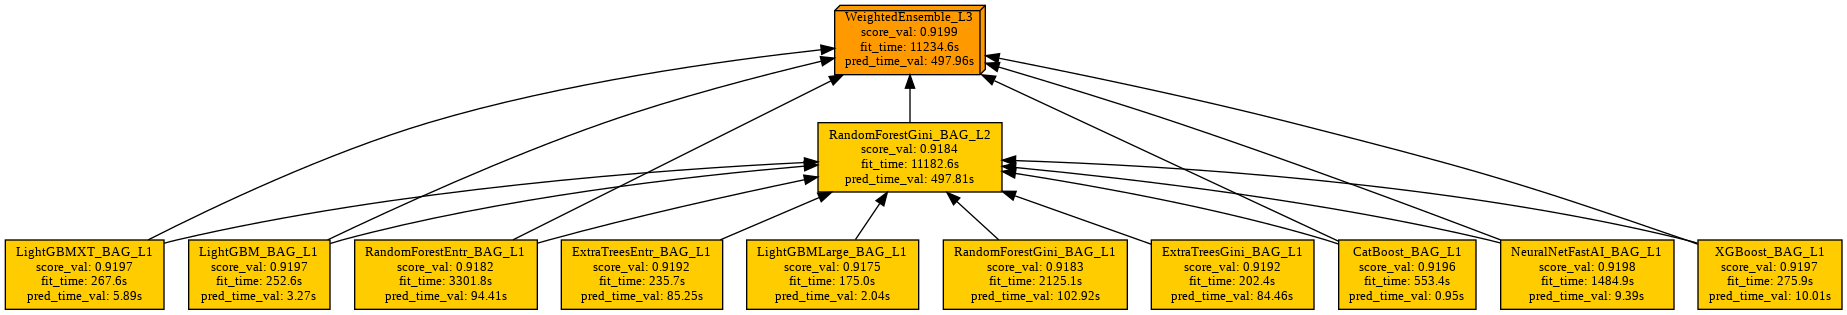

In [17]:
predictor.plot_ensemble_model(filename='ensemble_model.png')
display(Image(f'{MODELS_PATH}ensemble_model.png'))

In [18]:
# !zip -r /kaggle/working/AG_accident_models /kaggle/working/AG_accident_models.zip
# !zip -r {FOLDER}{NAME_EXT}.zip /kaggle/working/{FOLDER}{NAME_EXT}

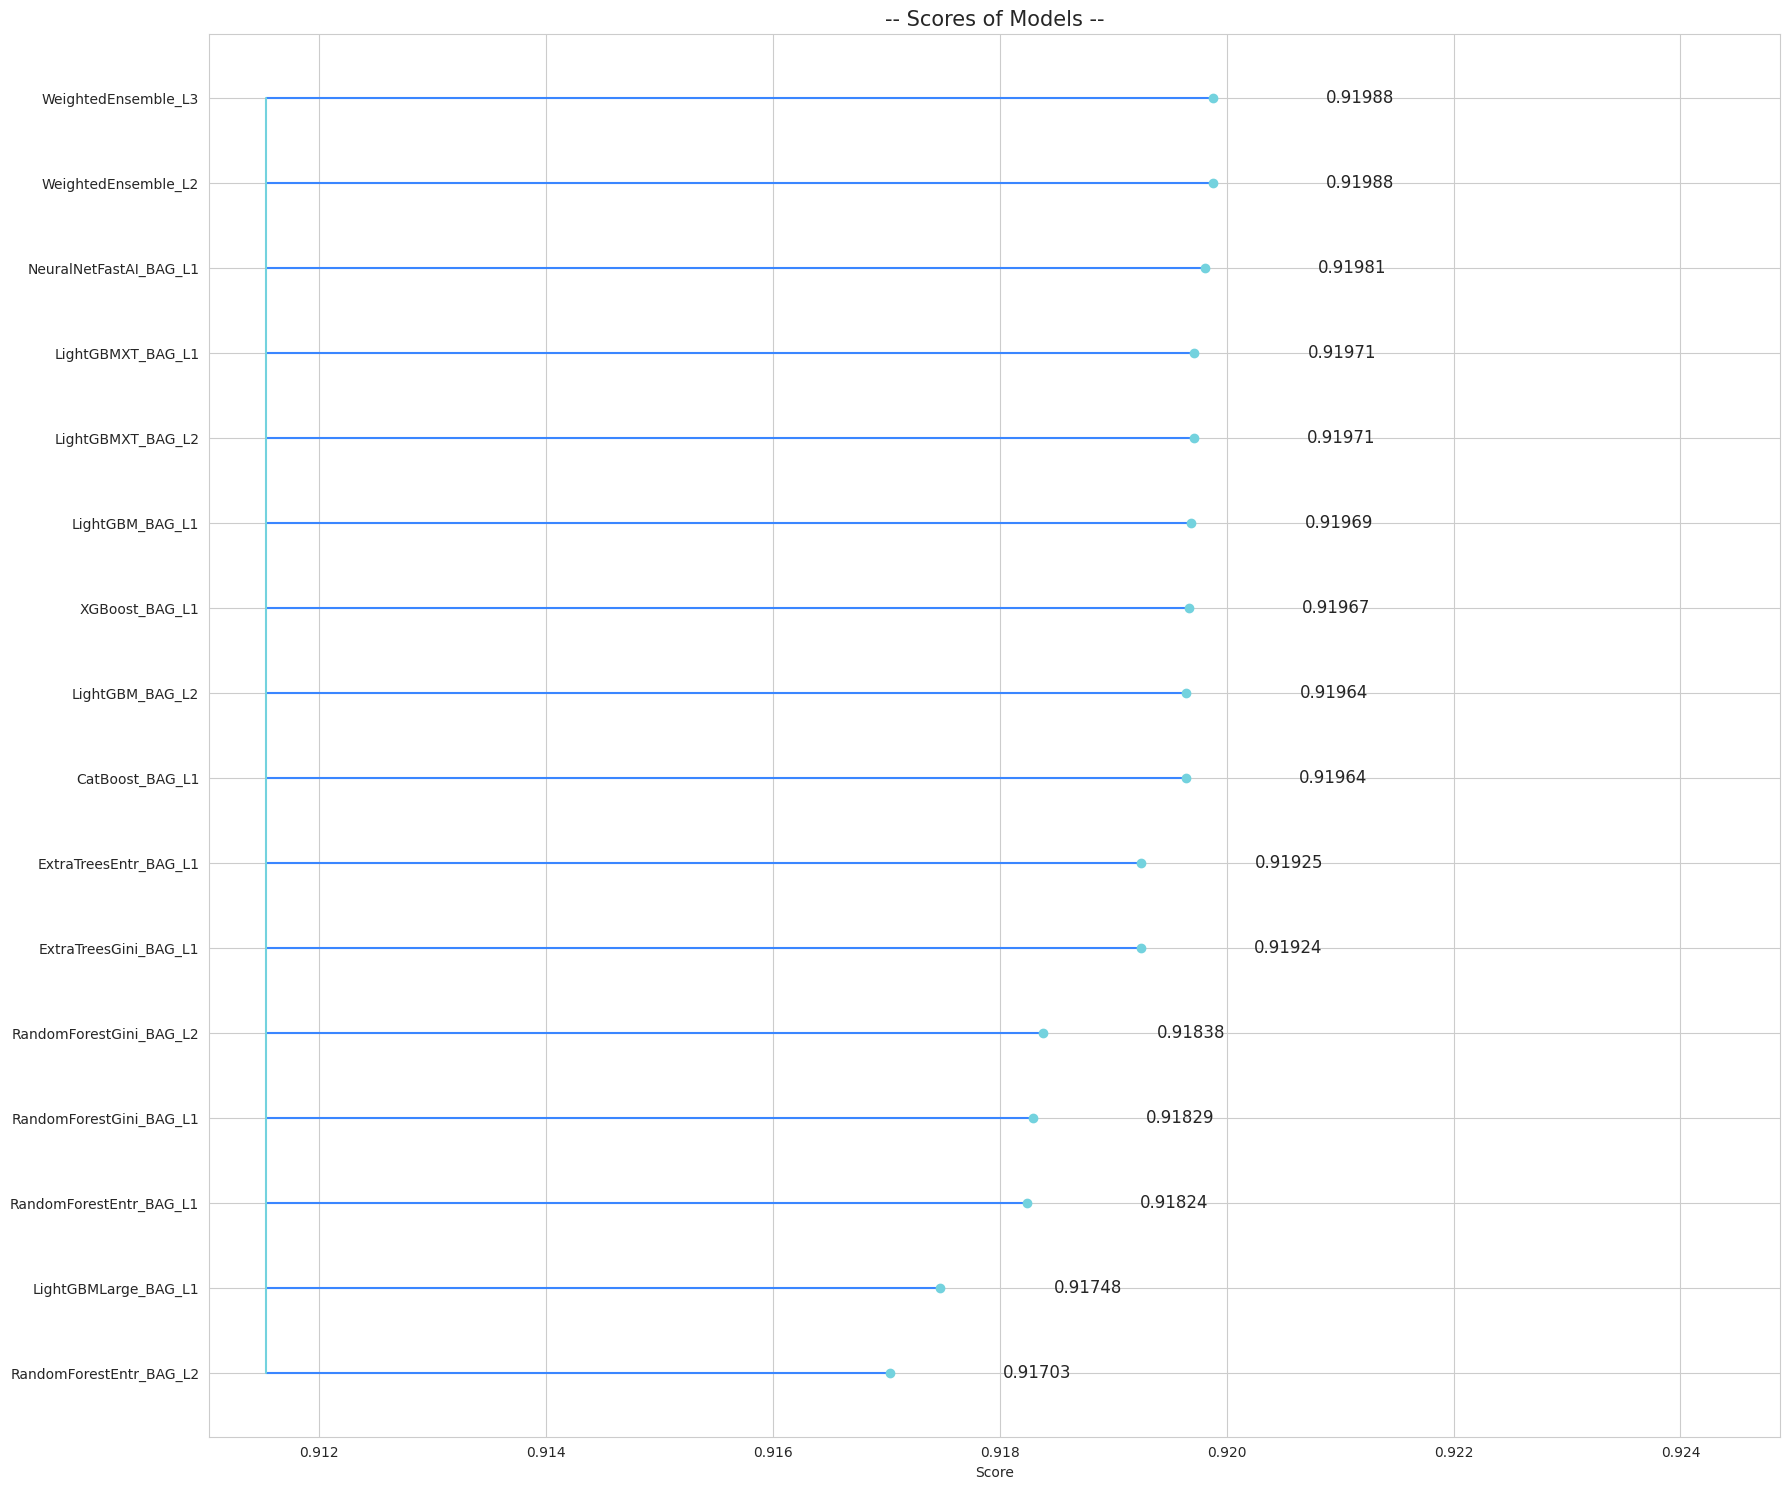

In [19]:
## -- Extract model scores --
result_ = dict(zip(leaderboard['model'], leaderboard['score_val']))
result_df = pd.DataFrame.from_dict(result_, orient='index').sort_values(0)

max_score = result_df.max().item()
min_score = result_df.min().item()

## -- PLOT MODELS & SCORES --
plt.figure(figsize=(18, 15))
plt.stem(
    result_df.index,
    result_df[0],
    orientation = 'horizontal',
    bottom = min_score - 0.0055,
    markerfmt = 'C3o'
)
plt.xlim(min_score - 0.006, max_score + 0.005)
plt.xlabel('Score')
plt.title('-- Scores of Models --', fontsize=15)

for i, value in enumerate(result_df[0]):
    plt.text(value+1e-3, i, f'{abs(value):.5f}', ha='left', va='center', fontdict=dict(size=12))

plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

In [20]:
# predictor.model_names()

In [21]:
# ## -- Permutation Feature Importances --
# feat_imp = predictor.feature_importance(
#                         data = X_test,
#                         # time_limit = 3600,
#                         # model = 'LightGBM_BAG_L1',
#                         # features = None,
#                         # feature_stage = 'transformed',
#                         # subsample_size = 5000,
#                         # num_shuffle_sets = 10,
#                         # include_confidence_band = True,
#                         confidence_level = 0.95,
#                         # silent = False
# ) 

# feat_imp.style.background_gradient(subset=["importance"], cmap="Spectral")

# plt.figure(figsize=(18, 35))
# sns.barplot(data=feat_imp, y=feat_imp.index, x=feat_imp.importance)
# plt.tick_params(axis='y', which='major', labelcolor='r')
# plt.title("Top Features by Permutation")
# plt.tight_layout()
# plt.show()

In [22]:
print(f"""
{'-'*48}
{'█'*5} | - AUTOGLUON NOTEBOOK COMPLETE! - | {'█'*5}
{'-'*48}
""")


------------------------------------------------
█████ | - AUTOGLUON NOTEBOOK COMPLETE! - | █████
------------------------------------------------



In [23]:
## -- OPTIONAL: Clear stored files in memory --
!rm -r {MODELS_PATH}